In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('mushrooms.csv')

In [3]:
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
# check missing values

data.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

## Explore the Data

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

class
e    4208
p    3916
Name: count, dtype: int64


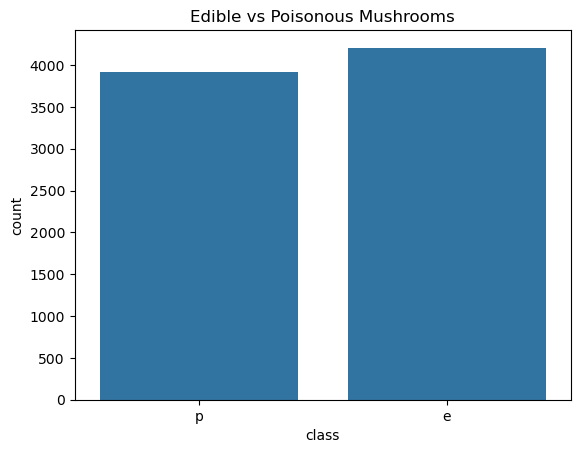

In [7]:
# check calss distribution

print(data['class'].value_counts())

sns.countplot(x='class', data=data)
plt.title('Edible vs Poisonous Mushrooms')
plt.show()

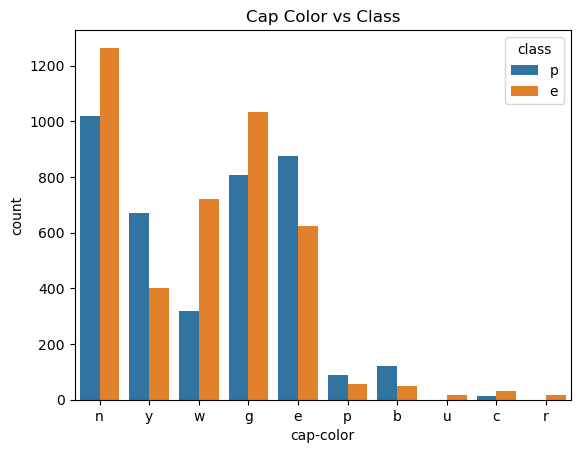

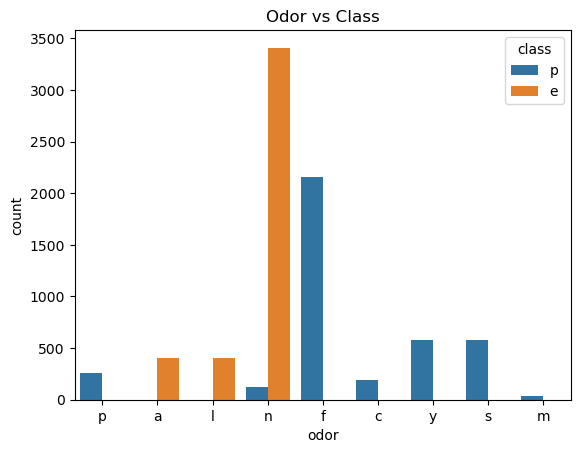

In [8]:
# explore a few features

sns.countplot(x='cap-color', hue='class', data=data)
plt.title('Cap Color vs Class')
plt.show()

sns.countplot(x='odor', hue='class', data=data)
plt.title('Odor vs Class')
plt.show()

## Preprocess the Data

In [9]:
# handle missing values

data['stalk-root'] = data['stalk-root'].replace('?', 'unknown')

In [11]:
from sklearn.preprocessing import LabelEncoder

# create a copy of the dataframe
data_encoded = data.copy()

# apply label encoder to each column
le = LabelEncoder()
for column in data_encoded.columns:
    data_encoded[column] = le.fit_transform(data_encoded[column])

# seperate features and target
X = data_encoded.drop('class', axis=1)
y = data_encoded['class']

## Split the Data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

## Train the model

In [13]:
from sklearn.tree import DecisionTreeClassifier

# initialize the model
model = DecisionTreeClassifier(random_state=42)

# train the model
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Evaluate the model

Accuracy: 1.00


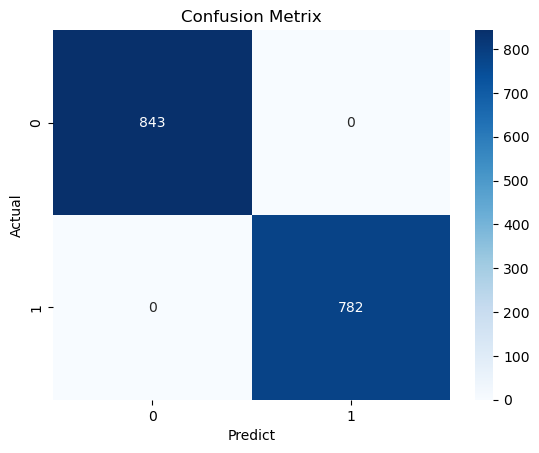

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       843
   Poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# make prediction
y_pred = model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# confusion metrics
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Metrix')
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.show()

# classification report
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

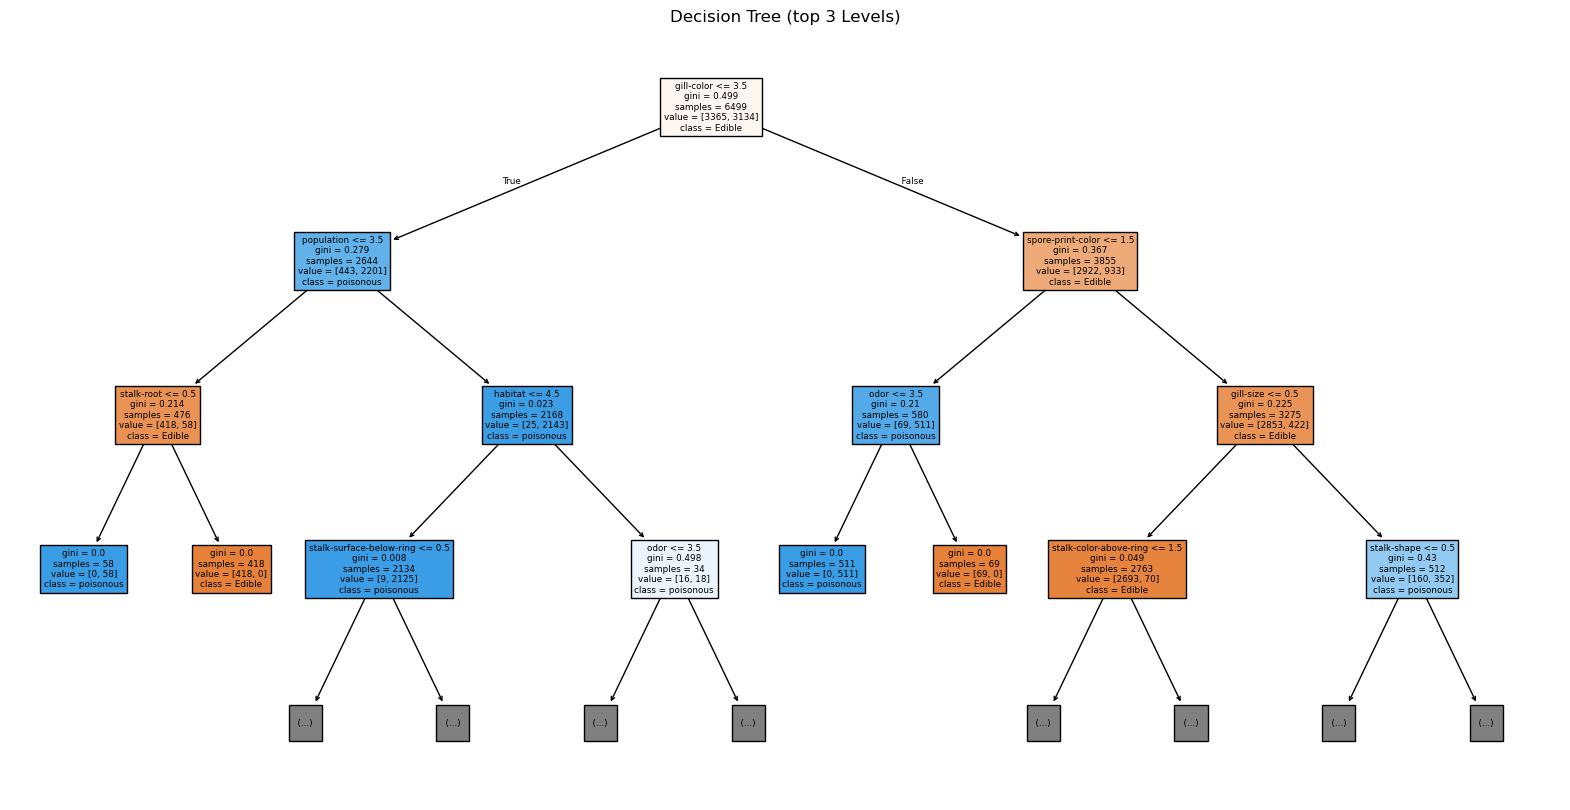

In [17]:
## Interpret the Model

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Edible', 'poisonous'], filled=True, max_depth=3)
plt.title('Decision Tree (top 3 Levels)')
plt.show()